# Figure 6 — Murine efficacy and safety

In vivo *A. baumannii* ATCC 19606 skin-scarification (A, B) and thigh-infection (D, E), plus proteolytic stability of leads (C). Reads the tidy `data/murine_skin.csv`, `data/murine_thigh.csv`, `data/proteolysis.csv`. Renders `../figures/figure6_murine.{pdf,png}`.


In [1]:
# Figure 6 -- murine efficacy + safety. House style (<=6.5x8 in, >=6 pt).
import csv, math, collections
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA = Path("../data")   # reads the built tidy files: murine_skin.csv, murine_thigh.csv, proteolysis.csv

plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 7, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 6,
    'axes.linewidth': 0.5, 'axes.edgecolor': 'grey',
    'xtick.color': '#555555', 'ytick.color': '#555555', 'axes.labelcolor': '#333333',
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.dpi': 300, 'savefig.dpi': 300,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'xtick.major.size': 2, 'ytick.major.size': 2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
PL = dict(fontsize=10, fontweight='bold', va='bottom', ha='left')

# groups per experiment, using canonical short_names (bZIP is a motif design -> Ω-MT-; LPS analogs -> Ω-AMT-)
SKIN  = ['Control','Ω-AT-BoCo1-5','Ω-AT-BoCo1-9','Ω-DP-52','Ω-DP-19','Ω-AMT-cecropin-1','Ω-AMT-cecropin-4','Polymyxin B']
THIGH = ['Control','Ω-MT-bZIP-8','Ω-AMT-pa4-1','Levofloxacin']
# dashboard (Tailwind) palette; a light/dark shade separates the two analogs of a family
COL = {'Control':'#292524',
    'Ω-AT-BoCo1-5':'#6ee7b7','Ω-AT-BoCo1-9':'#065f46',       # BoCo1 (green): light / dark
    'Ω-DP-52':'#a5b4fc','Ω-DP-19':'#3730a3',                 # de novo (indigo): light / dark
    'Ω-AMT-cecropin-1':'#f9a8d4','Ω-AMT-cecropin-4':'#9d174d',# cecropin (pink): light / dark
    'Polymyxin B':'#9ca3af',
    'Ω-MT-bZIP-8':'#3b82f6','Ω-AMT-pa4-1':'#14b8a6','Levofloxacin':'#9ca3af'}  # bZIP blue; pa4 teal
STAB = ['Ω-AP-Mammutin-1-4','Ω-AU-GQ20-4','Ω-MT-bZIP-8','Ω-AMT-pa4-1','Ω-AMT-sarcotoxin-4']
SCOL = {'Ω-AP-Mammutin-1-4':'#e11d48','Ω-AU-GQ20-4':'#f59e0b','Ω-MT-bZIP-8':'#3b82f6',
        'Ω-AMT-pa4-1':'#14b8a6','Ω-AMT-sarcotoxin-4':'#a855f7'}

# Dunn's vs Control -> significance code (exact p in the caption / source-data table)
PA = {'Day 2':{'Ω-AT-BoCo1-5':'ns','Ω-AT-BoCo1-9':'ns','Ω-DP-52':'ns','Ω-DP-19':'**',
               'Ω-AMT-cecropin-1':'***','Ω-AMT-cecropin-4':'***','Polymyxin B':'**'},
      'Day 4':{'Ω-AT-BoCo1-5':'ns','Ω-AT-BoCo1-9':'ns','Ω-DP-52':'ns','Ω-DP-19':'ns',
               'Ω-AMT-cecropin-1':'****','Ω-AMT-cecropin-4':'**','Polymyxin B':'****'}}
PD = {'Day 6':{'Ω-MT-bZIP-8':'ns','Ω-AMT-pa4-1':'ns','Levofloxacin':'****'},
      'Day 8':{'Ω-MT-bZIP-8':'***','Ω-AMT-pa4-1':'ns','Levofloxacin':'***'}}

def load_cfu(tidy_csv, day):
    """{short_name: [log10 CFU g^-1, ...]} for one model + day from data/murine_*.csv."""
    out = collections.defaultdict(list)
    for r in csv.DictReader(open(DATA / tidy_csv)):
        if r['assay'] == 'cfu' and int(float(r['day'])) == day:
            v = float(r['value'])
            if v > 0: out[r['short_name']].append(math.log10(v))
    return out

def load_weight(tidy_csv, groups):
    """(times, {short_name: (mean[], sem[])}) from the weight rows of data/murine_*.csv."""
    rows = [r for r in csv.DictReader(open(DATA / tidy_csv)) if r['assay'] == 'weight']
    times = sorted({int(float(r['day'])) for r in rows})
    stats = {}
    for g in groups:
        m, s = [], []
        for t in times:
            v = [float(r['value']) for r in rows if r['short_name'] == g and int(float(r['day'])) == t]
            m.append(np.mean(v) if v else np.nan)
            s.append(np.std(v) / math.sqrt(len(v)) if len(v) > 1 else 0)
        stats[g] = (np.array(m), np.array(s))
    return np.array(times, float), stats

def boxpanel(ax, tidy_csv, days, groups, sig, ylim):
    """Two day-blocks of box + jitter; significance code above each treatment box (vs Control)."""
    rng = np.random.RandomState(0); nG = len(groups); block = nG + 1.2
    for di, (day_label, day_int) in enumerate(days):
        cfu = load_cfu(tidy_csv, day_int); x0 = di * block; pos = [x0 + i for i in range(nG)]
        for i, g in enumerate(groups):
            vals = cfu.get(g, []); c = COL[g]
            ax.boxplot([vals], positions=[pos[i]], widths=0.62, patch_artist=True, showfliers=False, zorder=2,
                       medianprops=dict(color='#333333', lw=0.7), whiskerprops=dict(color=c, lw=0.8),
                       capprops=dict(color=c, lw=0.8), boxprops=dict(facecolor=c, edgecolor=c, alpha=0.60, lw=0.8))
            ax.scatter(pos[i] + (rng.rand(len(vals)) - 0.5) * 0.28, vals, s=5, color=c, edgecolor='#666', linewidth=0.2, zorder=3)
            if g in sig[day_label] and vals:
                ax.text(pos[i], max(vals) + 0.02 * (ylim[1] - ylim[0]) + 0.15, sig[day_label][g],
                        ha='center', va='bottom', fontsize=7, color='#333',
                        fontweight='bold' if sig[day_label][g] != 'ns' else 'normal')
        ax.text(x0 + (nG - 1) / 2, ylim[0] - 0.11 * (ylim[1] - ylim[0]), day_label, ha='center', va='top', fontsize=6, fontweight='bold')
    if len(days) > 1: ax.axvline(block - 0.6, ls=(0, (2, 2)), color='#bbb', lw=0.6)
    ax.set_xlim(-0.8, block * len(days) - 0.6); ax.set_ylim(*ylim); ax.set_xticks([])
    ax.set_ylabel(r'log$_{10}$ CFU g$^{-1}$')

def linepanel(ax, times, stats, groups, ylim, xlabel):
    for g in groups:
        m, s = stats[g]
        ax.errorbar(times, m, yerr=s, color=COL[g], lw=0.9, marker='o', ms=2.3, capsize=1.1, elinewidth=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel('Weight change (%)'); ax.set_ylim(*ylim); ax.set_xlim(times.min(), times.max())

def swatches(groups):
    return [plt.Line2D([0], [0], marker='s', ls='', ms=4, color=COL[g], label=g) for g in groups]

saved ../figures/figure6_murine.{pdf,png}


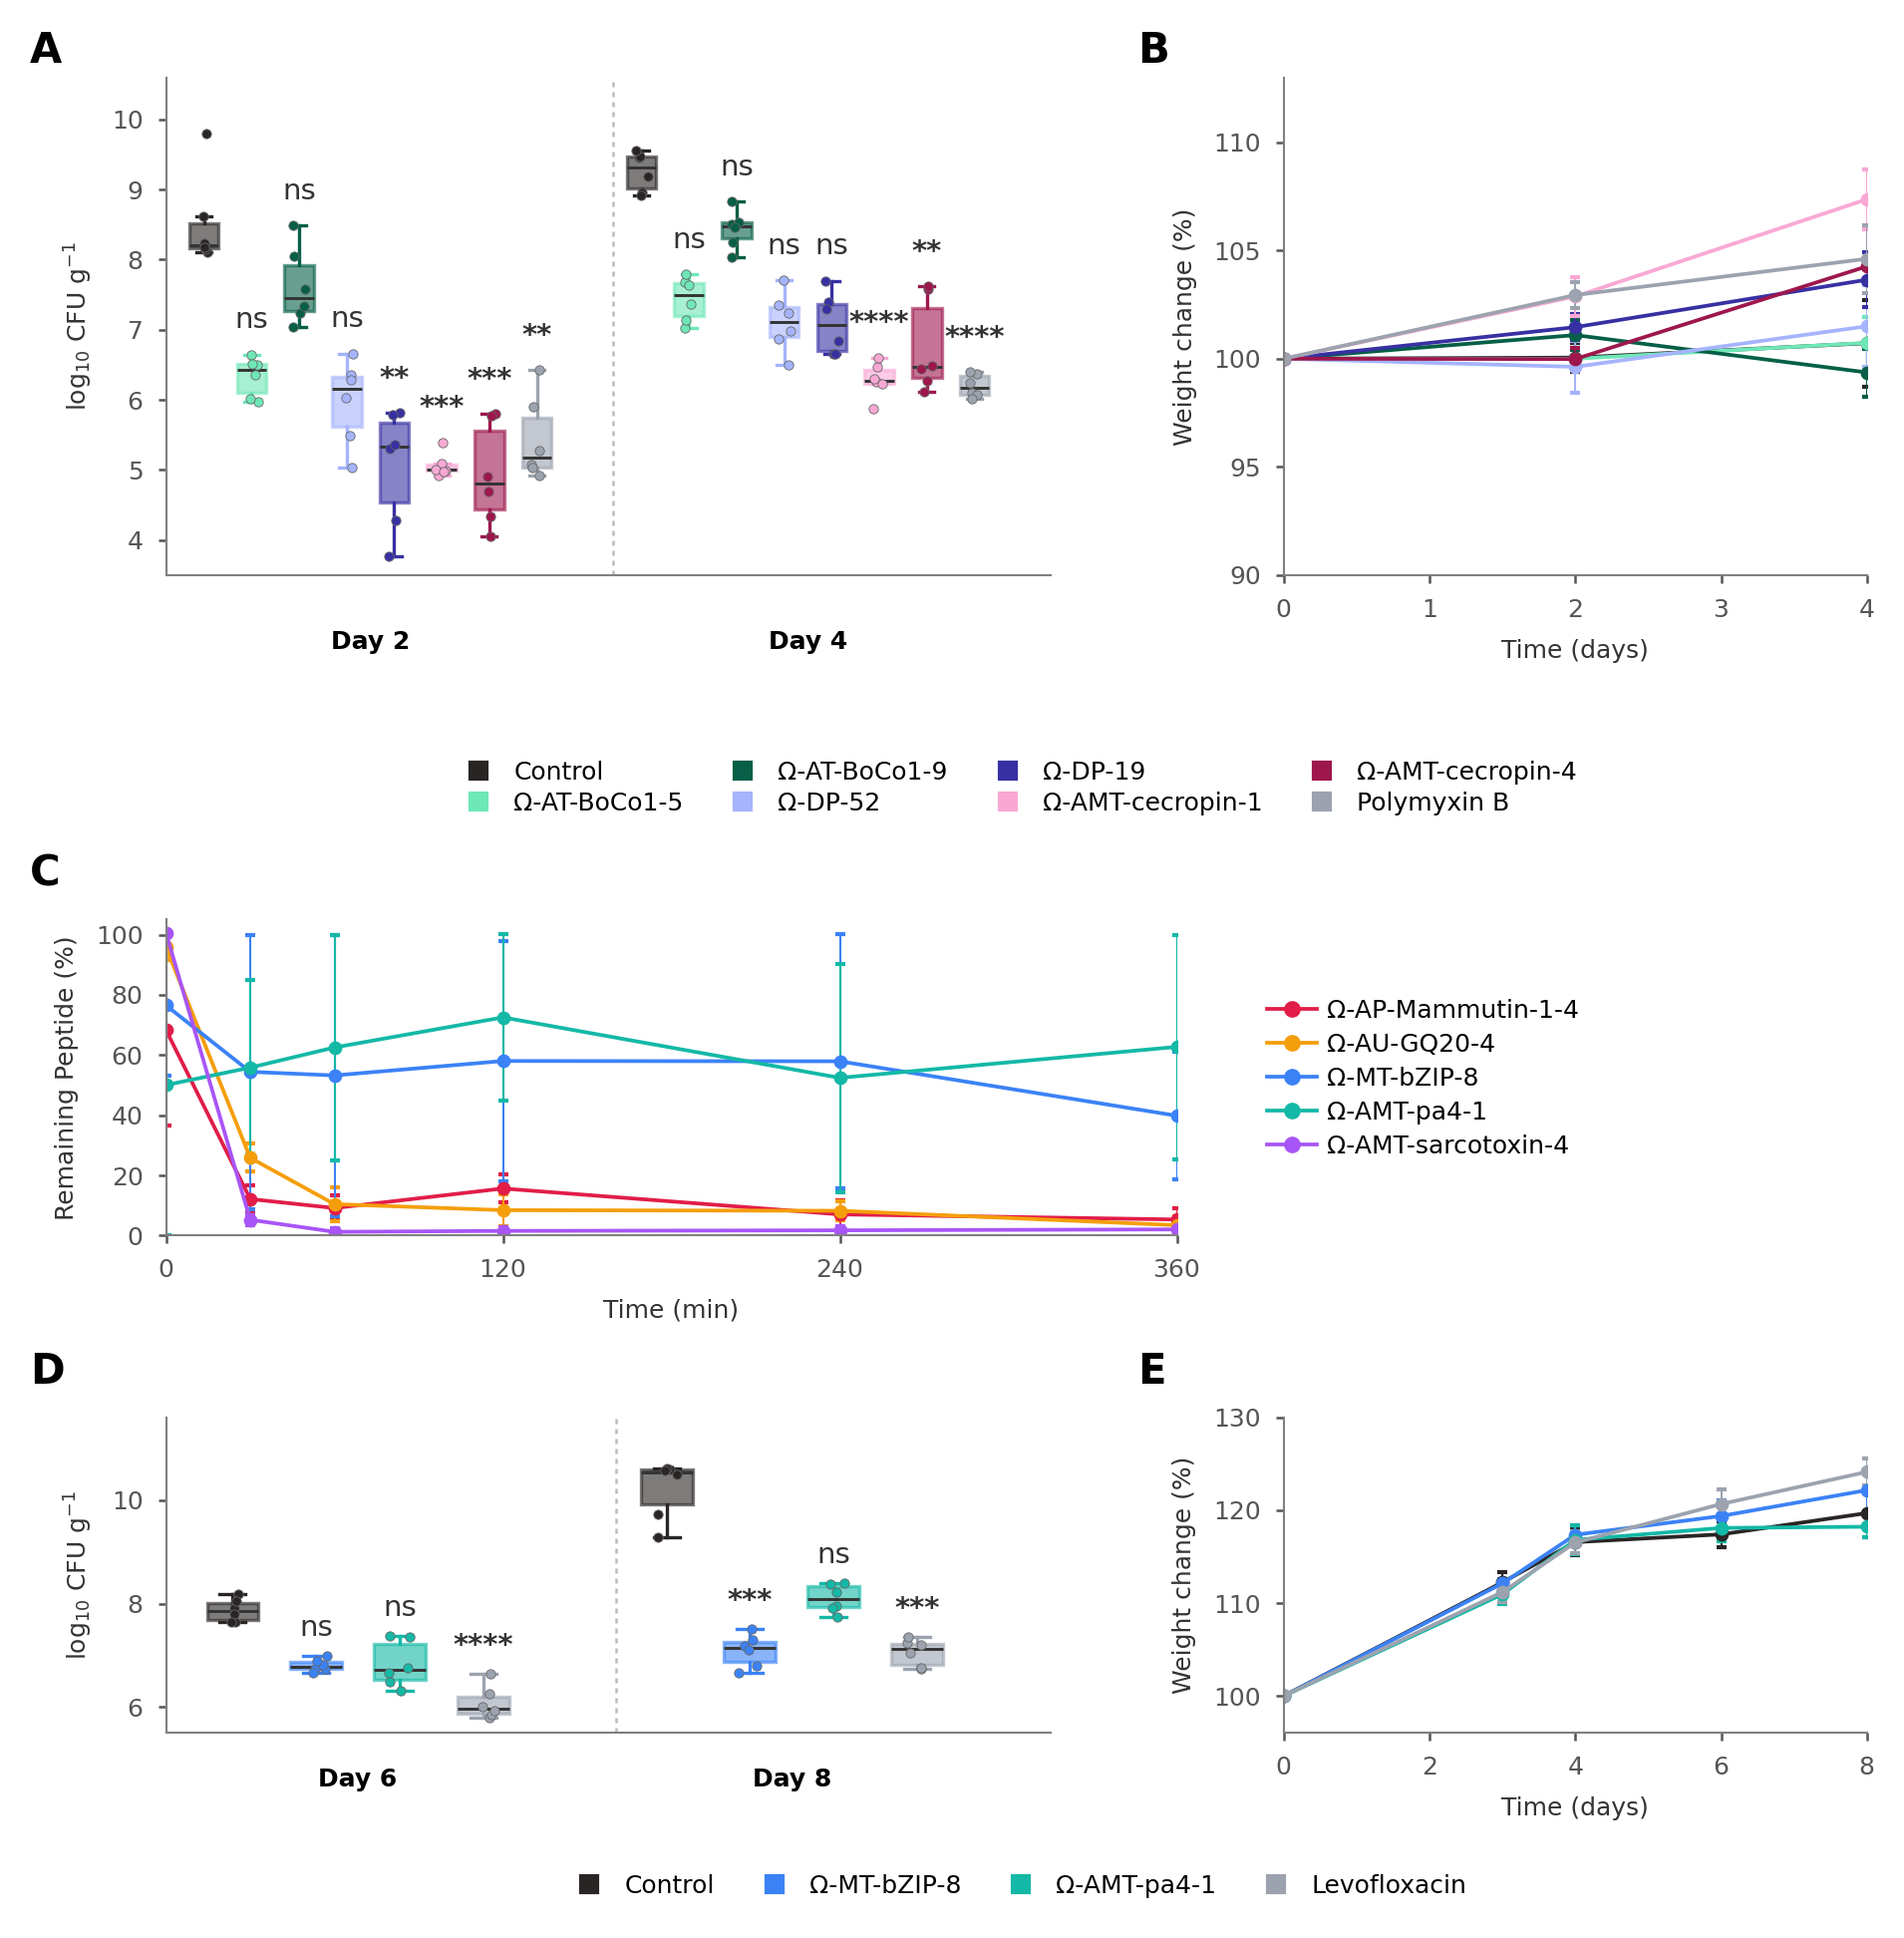

In [2]:
# Figure 6: A|B (skin, shared legend below), C (stability, legend right), D|E (thigh, shared legend below)
fig = plt.figure(figsize=(6.5, 6.4))
axA = fig.add_axes([0.085, 0.715, 0.455, 0.260])   # skin CFU
axB = fig.add_axes([0.660, 0.715, 0.300, 0.260])   # skin weight
axC = fig.add_axes([0.085, 0.370, 0.520, 0.165])   # stability
axD = fig.add_axes([0.085, 0.110, 0.455, 0.165])   # thigh CFU
axE = fig.add_axes([0.660, 0.110, 0.300, 0.165])   # thigh weight

# Row 1: A | B (skin) + shared legend below
boxpanel(axA, "murine_skin.csv", [('Day 2', 2), ('Day 4', 4)], SKIN, PA, (3.5, 10.6))
tB, sB = load_weight("murine_skin.csv", SKIN)
linepanel(axB, tB, sB, SKIN, (90, 113), 'Time (days)')
fig.text(0.015, 0.978, 'A', **PL); fig.text(0.585, 0.978, 'B', **PL)
fig.legend(handles=swatches(SKIN), loc='upper center', bbox_to_anchor=(0.522, 0.630), frameon=False,
           handletextpad=0.4, labelspacing=0.3, ncol=4, columnspacing=1.4)

# Row 2: C (stability, data/proteolysis.csv), legend to the right
_pro = collections.defaultdict(list)
for row in csv.DictReader(open(DATA / "proteolysis.csv")):
    _pro[row['short_name']].append((float(row['time_min']), float(row['rep1']), float(row['rep2']), float(row['mean'])))
for p in STAB:
    rec = sorted(_pro[p]); t = np.array([x[0] for x in rec]); m = np.array([x[3] for x in rec])
    err = np.array([abs(x[1] - x[2]) / 2 for x in rec])
    axC.errorbar(t, m, yerr=err, color=SCOL[p], lw=0.9, marker='o', ms=2.3, capsize=1.1, elinewidth=0.5)
axC.set_xlabel('Time (min)'); axC.set_ylabel('Remaining Peptide (%)'); axC.set_ylim(0, 105); axC.set_xlim(0, 360); axC.set_xticks([0, 120, 240, 360])
hC = [plt.Line2D([0], [0], marker='o', ls='-', lw=0.9, ms=3, color=SCOL[p], label=p) for p in STAB]
fig.legend(handles=hC, loc='center left', bbox_to_anchor=(0.640, 0.452), frameon=False, handletextpad=0.4, labelspacing=0.4)
fig.text(0.015, 0.548, 'C', **PL)

# Row 3: D | E (thigh) + shared legend below
boxpanel(axD, "murine_thigh.csv", [('Day 6', 6), ('Day 8', 8)], THIGH, PD, (5.5, 11.6))
tE, sE = load_weight("murine_thigh.csv", THIGH)
linepanel(axE, tE, sE, THIGH, (96, 130), 'Time (days)')
fig.text(0.015, 0.288, 'D', **PL); fig.text(0.585, 0.288, 'E', **PL)
fig.legend(handles=swatches(THIGH), loc='upper center', bbox_to_anchor=(0.522, 0.048), frameon=False,
           handletextpad=0.4, labelspacing=0.3, ncol=4, columnspacing=1.4)

import os; os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/figure6_murine.pdf", bbox_inches='tight')
fig.savefig("../figures/figure6_murine.png", dpi=200, bbox_inches='tight')
print("saved ../figures/figure6_murine.{pdf,png}")